# 下注策略分析

**問題**：固定金額 vs 固定比例，哪個比較好？最佳參數是多少？

**方法**：對前四名城市（Miami / Seattle / London / Paris）做參數掃描，並計算 Kelly 最佳比例作為理論上限。

---

In [11]:
# ── 分析城市（限前四名高勝率城市）────────────────────────────────────────────
TARGET_CITIES = [
    "us/fl/miami/KMIA",
    "us/wa/seatac/KSEA",
    "gb/london/EGLC",
    "fr/paris/LFPG",
]

# ── 進場設定（與 backtest_notebook 一致）────────────────────────────────────
LEAD_HOURS   = 24
LEAD_TOL     = 1.5
SETTLE_RULE  = "nearest"
MAX_PROB     = 0.8
PEAK_FEE     = 0.0125
INITIAL_CAP  = 100.0

# ── 參數掃描範圍 ──────────────────────────────────────────────────────────────
FIXED_BETS   = [0.5, 1, 2, 3, 5, 7, 10, 15, 20]   # 固定金額（$）
FRACTIONS    = [0.01, 0.02, 0.03, 0.05, 0.07,
                0.10, 0.15, 0.20, 0.25, 0.30]        # 固定比例（%）

In [12]:
import os, re
from pathlib import Path
from collections import defaultdict

import numpy as np
import psycopg2
import psycopg2.extras
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

plt.rcParams["font.family"] = ["Arial Unicode MS", "Heiti TC", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

load_dotenv(Path("..") / ".env")

CITY_NAMES = {
    "us/fl/miami/KMIA":  "Miami",
    "us/wa/seatac/KSEA": "Seattle",
    "gb/london/EGLC":    "London",
    "fr/paris/LFPG":     "Paris",
}

_RANGE_RE = re.compile(r"(-?\d+)\s*-\s*(-?\d+)")
_BOUND_RE = re.compile(r"(-?\d+)\s*°?[CF]?\s*(or higher|or above|or below)", re.I)

def covers(label, actual, rule="nearest"):
    m = _BOUND_RE.search(label)
    if m:
        t = int(m.group(1)); tail = m.group(2).lower()
        return actual >= t if ("high" in tail or "above" in tail) else actual < t + 1
    m = _RANGE_RE.search(label)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return lo <= actual < hi + 1
    m = re.search(r"(-?\d+)", label)
    if m:
        t = int(m.group(1))
        return abs(actual - t) < 0.5 if rule == "nearest" else t <= actual < t + 1
    return False

def f_to_c(f): return (f - 32) * 5 / 9
def taker_fee(p, peak): return peak * 4 * p * (1 - p)

print("✅ 套件載入完成")

✅ 套件載入完成


In [13]:
def load_city_data(conn, loc, lead_hours, tol):
    lo, hi = lead_hours - tol, lead_hours + tol
    sql = """
    WITH snaps AS (
      SELECT DISTINCT ON (market_date)
             market_date, snapshot_time, hours_before_close
      FROM market_snapshots
      WHERE location_key = %s AND hours_before_close BETWEEN %s AND %s
      ORDER BY market_date, ABS(hours_before_close - %s) ASC
    )
    SELECT s.market_date, ms.option_label, ms.yes_prob,
           wds.official_high_f, c.celsius
    FROM snaps s
    JOIN market_snapshots ms
      ON ms.location_key = %s AND ms.market_date = s.market_date
     AND ms.snapshot_time = s.snapshot_time
    JOIN weather_daily_summary wds
      ON wds.location_key = %s AND wds.obs_date = s.market_date
    JOIN cities c ON c.location_key = %s
    WHERE wds.official_high_f IS NOT NULL AND ms.yes_prob IS NOT NULL
    ORDER BY s.market_date, ms.yes_prob DESC
    """
    with conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor) as cur:
        cur.execute(sql, (loc, lo, hi, lead_hours, loc, loc, loc))
        rows = cur.fetchall()
    days = defaultdict(list)
    for r in rows:
        days[r["market_date"]].append({
            "label":   r["option_label"],
            "p":       float(r["yes_prob"]),
            "high_f":  float(r["official_high_f"]),
            "celsius": r["celsius"],
        })
    return [{"date": d, "opts": v} for d, v in sorted(days.items())]


def run_backtest(data, strategy, initial, fixed_bet, fraction, rule, max_prob, peak_fee):
    capital, records = initial, []
    for day in data:
        top = sorted(day["opts"], key=lambda o: -o["p"])[0]
        if top["p"] > max_prob:
            continue
        actual = f_to_c(top["high_f"]) if top["celsius"] else top["high_f"]
        won    = covers(top["label"], actual, rule)
        bet    = fixed_bet if strategy == "fixed" else capital * fraction
        fee    = bet * taker_fee(top["p"], peak_fee)
        gross  = bet * (1 / top["p"] - 1) if won else -bet
        net    = gross - fee
        capital += net
        records.append({"won": won, "bet": bet, "p": top["p"],
                         "gross": gross, "net": net, "capital": capital})
    return pd.DataFrame(records)


def max_drawdown(capitals):
    """最大回撤（絕對金額）"""
    peak = capitals[0]
    mdd = 0.0
    for c in capitals:
        peak = max(peak, c)
        mdd  = max(mdd, peak - c)
    return mdd


conn = psycopg2.connect(os.environ["DATABASE_URL"], sslmode="require")

# 預先載入四城市資料
city_data = {}
for loc in TARGET_CITIES:
    city_data[loc] = load_city_data(conn, loc, LEAD_HOURS, LEAD_TOL)
    print(f"  {CITY_NAMES[loc]}: {len(city_data[loc])} 天")

print("✅ 資料載入完成")

  Miami: 50 天
  Seattle: 50 天
  London: 48 天
  Paris: 50 天
✅ 資料載入完成


## 📊 參數掃描：最終資本 vs 參數大小

In [14]:
# ── 掃描兩種策略的所有參數 ───────────────────────────────────────────────────
sweep_fixed = defaultdict(dict)   # sweep_fixed[loc][bet] = {final, mdd, roi}
sweep_frac  = defaultdict(dict)

for loc in TARGET_CITIES:
    data = city_data[loc]
    for bet in FIXED_BETS:
        df = run_backtest(data, "fixed", INITIAL_CAP, bet, 0, SETTLE_RULE, MAX_PROB, PEAK_FEE)
        if df.empty: continue
        caps = [INITIAL_CAP] + list(df["capital"])
        sweep_fixed[loc][bet] = {
            "final": df["capital"].iloc[-1],
            "mdd":   max_drawdown(caps),
            "roi":   (df["capital"].iloc[-1] - INITIAL_CAP) / INITIAL_CAP * 100,
            "total_bet": df["bet"].sum(),
        }
    for frac in FRACTIONS:
        df = run_backtest(data, "fractional", INITIAL_CAP, 0, frac, SETTLE_RULE, MAX_PROB, PEAK_FEE)
        if df.empty: continue
        caps = [INITIAL_CAP] + list(df["capital"])
        sweep_frac[loc][frac] = {
            "final": df["capital"].iloc[-1],
            "mdd":   max_drawdown(caps),
            "roi":   (df["capital"].iloc[-1] - INITIAL_CAP) / INITIAL_CAP * 100,
            "total_bet": df["bet"].sum(),
        }

print("✅ 參數掃描完成")

✅ 參數掃描完成


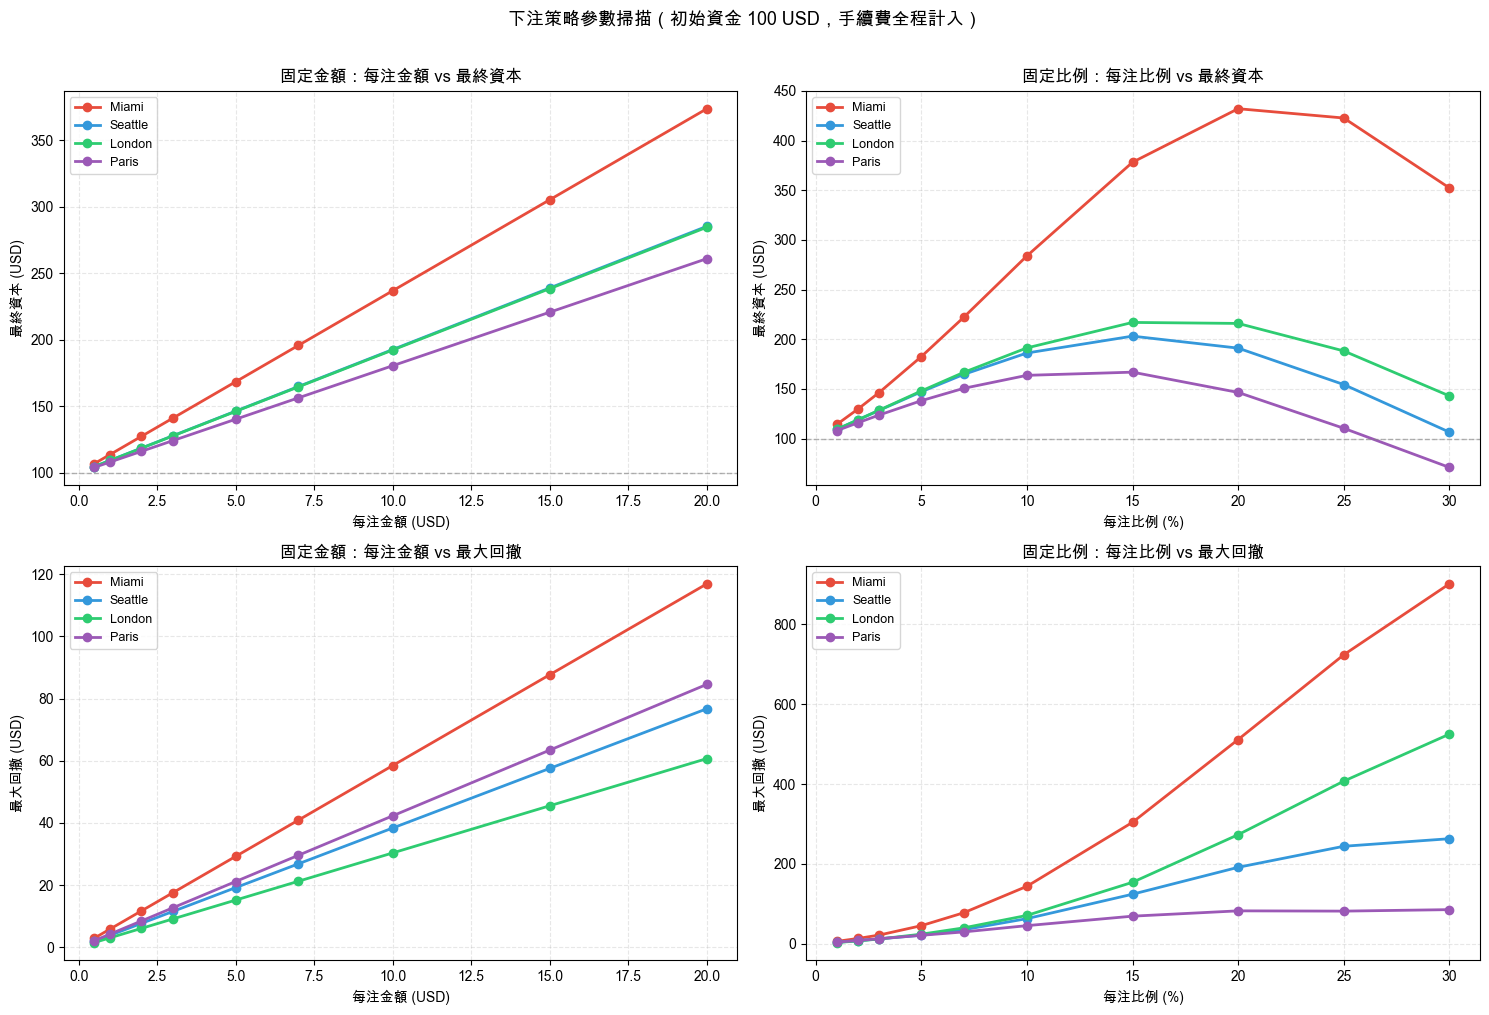

In [15]:
colors = {"Miami": "#e74c3c", "Seattle": "#3498db",
          "London": "#2ecc71", "Paris":   "#9b59b6"}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── 左上：固定金額 → 最終資本 ─────────────────────────────────────────────────
ax = axes[0, 0]
for loc in TARGET_CITIES:
    name = CITY_NAMES[loc]
    xs = sorted(sweep_fixed[loc].keys())
    ys = [sweep_fixed[loc][x]["final"] for x in xs]
    ax.plot(xs, ys, marker="o", color=colors[name], linewidth=2, label=name)
ax.axhline(INITIAL_CAP, color="gray", linewidth=1, linestyle="--", alpha=0.6)
ax.set_title("固定金額：每注金額 vs 最終資本", fontsize=12, fontweight="bold")
ax.set_xlabel("每注金額 (USD)", fontsize=10)
ax.set_ylabel("最終資本 (USD)", fontsize=10)
ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.3)

# ── 右上：固定比例 → 最終資本 ─────────────────────────────────────────────────
ax = axes[0, 1]
for loc in TARGET_CITIES:
    name = CITY_NAMES[loc]
    xs = sorted(sweep_frac[loc].keys())
    ys = [sweep_frac[loc][x]["final"] for x in xs]
    ax.plot([x*100 for x in xs], ys, marker="o",
            color=colors[name], linewidth=2, label=name)
ax.axhline(INITIAL_CAP, color="gray", linewidth=1, linestyle="--", alpha=0.6)
ax.set_title("固定比例：每注比例 vs 最終資本", fontsize=12, fontweight="bold")
ax.set_xlabel("每注比例 (%)", fontsize=10)
ax.set_ylabel("最終資本 (USD)", fontsize=10)
ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.3)

# ── 左下：固定金額 → 最大回撤 ────────────────────────────────────────────────
ax = axes[1, 0]
for loc in TARGET_CITIES:
    name = CITY_NAMES[loc]
    xs = sorted(sweep_fixed[loc].keys())
    ys = [sweep_fixed[loc][x]["mdd"] for x in xs]
    ax.plot(xs, ys, marker="o", color=colors[name], linewidth=2, label=name)
ax.set_title("固定金額：每注金額 vs 最大回撤", fontsize=12, fontweight="bold")
ax.set_xlabel("每注金額 (USD)", fontsize=10)
ax.set_ylabel("最大回撤 (USD)", fontsize=10)
ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.3)

# ── 右下：固定比例 → 最大回撤 ────────────────────────────────────────────────
ax = axes[1, 1]
for loc in TARGET_CITIES:
    name = CITY_NAMES[loc]
    xs = sorted(sweep_frac[loc].keys())
    ys = [sweep_frac[loc][x]["mdd"] for x in xs]
    ax.plot([x*100 for x in xs], ys, marker="o",
            color=colors[name], linewidth=2, label=name)
ax.set_title("固定比例：每注比例 vs 最大回撤", fontsize=12, fontweight="bold")
ax.set_xlabel("每注比例 (%)", fontsize=10)
ax.set_ylabel("最大回撤 (USD)", fontsize=10)
ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.3)

plt.suptitle(f"下注策略參數掃描（初始資金 {INITIAL_CAP:.0f} USD，手續費全程計入）",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 📐 Kelly 最佳比例計算

Kelly 公式給出**理論上長期資本成長最大化的下注比例**：

$$f^* = \frac{p \cdot b - q}{b} = p - \frac{q}{b}$$

- $p$ = 勝率，$q = 1-p$
- $b$ = 淨賠率（贏 $1 得到 $b），即 $\frac{1}{\text{yes\_prob}} - 1$
- 因為每筆賠率不同，這裡用**加權平均 Kelly**

實務上通常用 **Half Kelly（$f^*/2$）** 降低波動。

In [16]:
print(f"{'城市':<10} {'勝率':>6} {'平均賠率':>8} {'Kelly':>8} {'Half Kelly':>10} {'建議比例':>10}")
print("-" * 58)

kelly_results = {}
for loc in TARGET_CITIES:
    data = city_data[loc]
    rows = []
    for day in data:
        top = sorted(day["opts"], key=lambda o: -o["p"])[0]
        if top["p"] > MAX_PROB:
            continue
        actual = f_to_c(top["high_f"]) if top["celsius"] else top["high_f"]
        won    = covers(top["label"], actual, SETTLE_RULE)
        b      = 1 / top["p"] - 1   # 淨賠率
        fee_r  = taker_fee(top["p"], PEAK_FEE)
        # 有效賠率（扣手續費）
        b_eff  = b - fee_r           # 贏的淨收益率
        loss_eff = 1 + fee_r         # 輸的損失率
        rows.append({"won": won, "p": top["p"], "b": b, "b_eff": b_eff, "loss_eff": loss_eff})

    df_k  = pd.DataFrame(rows)
    win_r = df_k["won"].mean()
    avg_b = df_k["b"].mean()

    # 逐筆 Kelly，取平均
    df_k["kelly"] = df_k.apply(
        lambda r: max(0, r["won"] - (1 - r["won"]) / r["b_eff"])
        if r["b_eff"] > 0 else 0, axis=1
    )
    # 用實際勝率算 Kelly（每筆的 p 已知是市場賠率，勝率用 empirical）
    kelly_per_row = df_k.apply(
        lambda r: max(0, (win_r * r["b_eff"] - (1 - win_r) * r["loss_eff"]) / (r["b_eff"] * r["loss_eff"])),
        axis=1
    )
    kelly_f    = kelly_per_row.mean()
    half_kelly = kelly_f / 2
    rec        = min(half_kelly, 0.10)   # 上限 10%

    kelly_results[loc] = {"win_rate": win_r, "avg_b": avg_b,
                           "kelly": kelly_f, "half_kelly": half_kelly, "rec": rec}
    name = CITY_NAMES[loc]
    print(f"  {name:<8} {win_r:>6.1%} {avg_b:>8.3f} {kelly_f:>8.1%} {half_kelly:>10.1%} {rec:>10.1%}")

城市             勝率     平均賠率    Kelly Half Kelly       建議比例
----------------------------------------------------------
  Miami     58.0%    1.261    21.2%      10.6%      10.0%
  Seattle   54.2%    1.186    13.4%       6.7%       6.7%
  London    57.8%    1.162    17.8%       8.9%       8.9%
  Paris     51.1%    1.374    14.2%       7.1%       7.1%


## 📈 固定金額 vs 固定比例：同等初始注額的成長對比

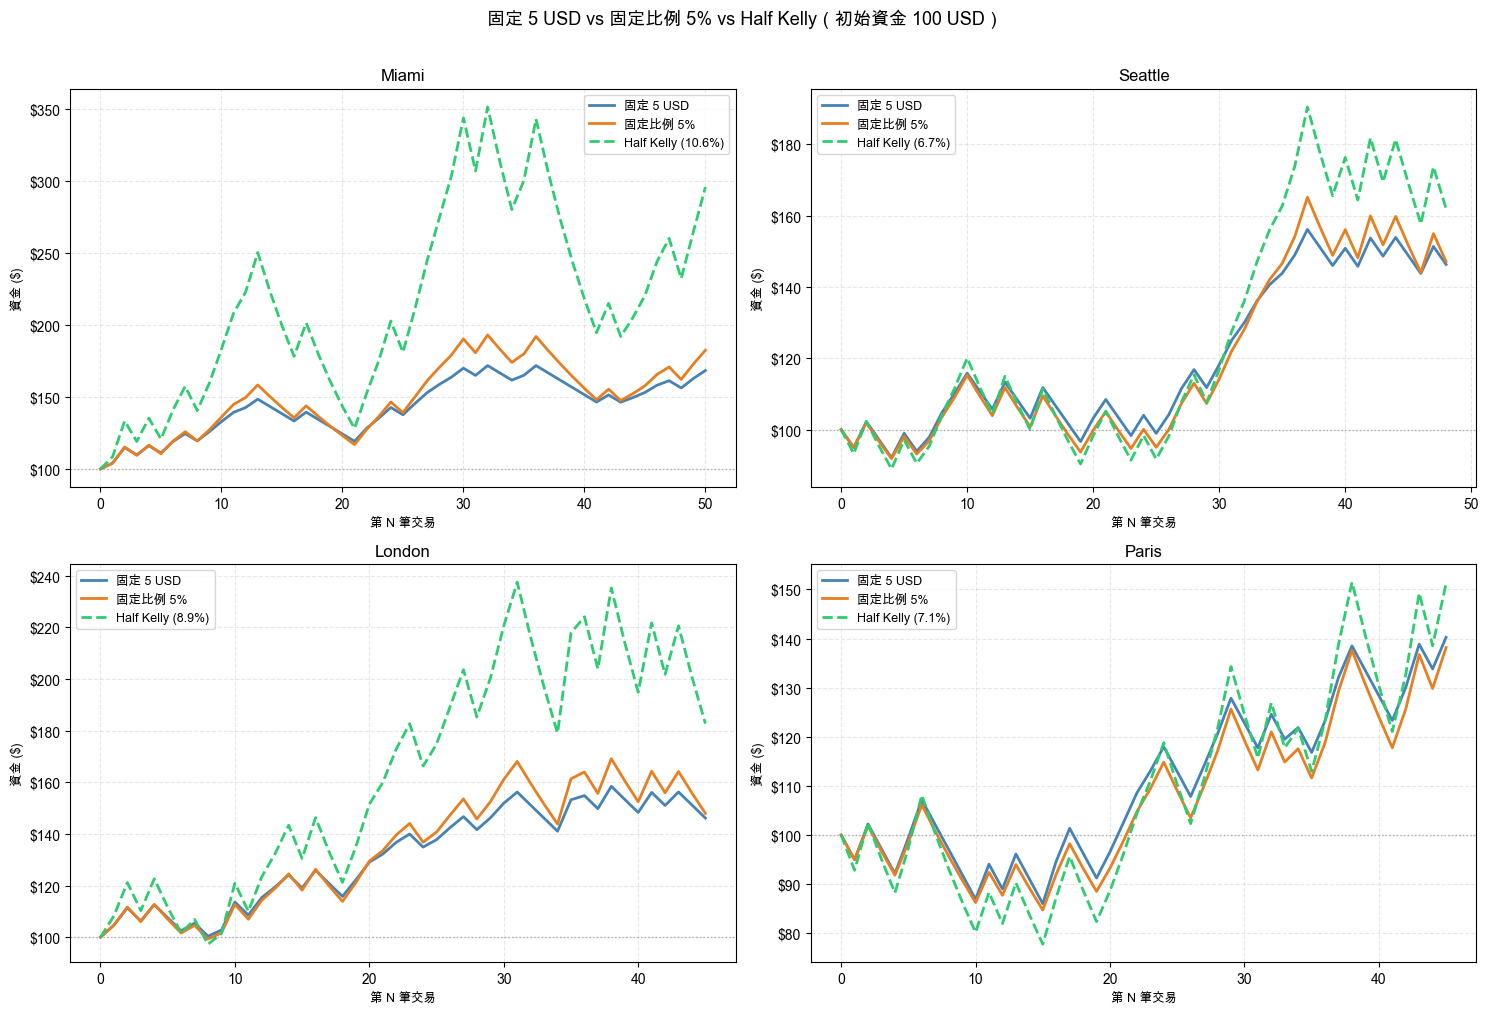

In [17]:
# 比較基準：固定金額 5 USD vs 固定比例 5%（初始注額相同）
# 額外加入 Half Kelly 比例

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, loc in enumerate(TARGET_CITIES):
    ax   = axes[idx]
    name = CITY_NAMES[loc]
    data = city_data[loc]
    hk   = kelly_results[loc]["half_kelly"]
    hk   = min(hk, 0.25)   # 上限 25%

    df_fx = run_backtest(data, "fixed",      INITIAL_CAP, 5,   0,  SETTLE_RULE, MAX_PROB, PEAK_FEE)
    df_f5 = run_backtest(data, "fractional", INITIAL_CAP, 0,   0.05, SETTLE_RULE, MAX_PROB, PEAK_FEE)
    df_hk = run_backtest(data, "fractional", INITIAL_CAP, 0,   hk,   SETTLE_RULE, MAX_PROB, PEAK_FEE)

    x = range(len(df_fx) + 1)
    ax.plot(x, [INITIAL_CAP] + list(df_fx["capital"]),
            color="steelblue", linewidth=2, label="固定 5 USD")
    ax.plot(x, [INITIAL_CAP] + list(df_f5["capital"]),
            color="#e67e22", linewidth=2, label="固定比例 5%")
    ax.plot(x, [INITIAL_CAP] + list(df_hk["capital"]),
            color="#2ecc71", linewidth=2, linestyle="--",
            label=f"Half Kelly ({hk*100:.1f}%)")
    ax.axhline(INITIAL_CAP, color="gray", linewidth=1, linestyle=":", alpha=0.6)
    ax.set_title(f"{name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("第 N 筆交易", fontsize=9)
    ax.set_ylabel("資金 ($)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.3)

plt.suptitle("固定 5 USD vs 固定比例 5% vs Half Kelly（初始資金 100 USD）",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 📋 策略建議總結

In [18]:
print("=" * 65)
print("策略建議總結（初始資金 $100，手續費全程計入）")
print("=" * 65)

for loc in TARGET_CITIES:
    name = CITY_NAMES[loc]
    data = city_data[loc]
    kr   = kelly_results[loc]

    # 找固定金額最佳注額（最終資本最高）
    best_fixed_bet = max(sweep_fixed[loc], key=lambda x: sweep_fixed[loc][x]["final"])
    best_fixed_res = sweep_fixed[loc][best_fixed_bet]

    # 找固定比例最佳（最終資本最高）
    best_frac     = max(sweep_frac[loc], key=lambda x: sweep_frac[loc][x]["final"])
    best_frac_res = sweep_frac[loc][best_frac]

    print(f"\n  【{name}】 勝率={kr['win_rate']:.1%}  Kelly={kr['kelly']:.1%}  Half Kelly={kr['half_kelly']:.1%}")
    print(f"    固定金額最佳：${best_fixed_bet}/注  → 最終 ${best_fixed_res['final']:.2f}  "
          f"MDD=${best_fixed_res['mdd']:.2f}")
    print(f"    固定比例最佳：{best_frac*100:.0f}%/注  → 最終 ${best_frac_res['final']:.2f}  "
          f"MDD=${best_frac_res['mdd']:.2f}")
    print(f"    建議：Half Kelly = {min(kr['half_kelly'], 0.10)*100:.1f}%")

print("\n" + "=" * 65)
print("通則：")
print("  - 固定比例在正期望值策略中長期勝出，但波動更大")
print("  - Half Kelly 是理論最佳比例的保守版（降低 50% 避免過度下注）")
print("  - 固定金額適合初期測試真實邊際效益，確認後再換固定比例")
print("  - 若帳戶 < $200，建議先用固定金額 $1-$3 確認 live 勝率")

策略建議總結（初始資金 $100，手續費全程計入）

  【Miami】 勝率=58.0%  Kelly=21.2%  Half Kelly=10.6%
    固定金額最佳：$20/注  → 最終 $373.64  MDD=$116.95
    固定比例最佳：20%/注  → 最終 $432.01  MDD=$511.25
    建議：Half Kelly = 10.0%

  【Seattle】 勝率=54.2%  Kelly=13.4%  Half Kelly=6.7%
    固定金額最佳：$20/注  → 最終 $285.25  MDD=$76.75
    固定比例最佳：15%/注  → 最終 $203.13  MDD=$124.26
    建議：Half Kelly = 6.7%

  【London】 勝率=57.8%  Kelly=17.8%  Half Kelly=8.9%
    固定金額最佳：$20/注  → 最終 $284.55  MDD=$60.71
    固定比例最佳：15%/注  → 最終 $216.94  MDD=$154.09
    建議：Half Kelly = 8.9%

  【Paris】 勝率=51.1%  Kelly=14.2%  Half Kelly=7.1%
    固定金額最佳：$20/注  → 最終 $260.93  MDD=$84.60
    固定比例最佳：15%/注  → 最終 $166.89  MDD=$69.34
    建議：Half Kelly = 7.1%

通則：
  - 固定比例在正期望值策略中長期勝出，但波動更大
  - Half Kelly 是理論最佳比例的保守版（降低 50% 避免過度下注）
  - 固定金額適合初期測試真實邊際效益，確認後再換固定比例
  - 若帳戶 < $200，建議先用固定金額 $1-$3 確認 live 勝率
